In [9]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,SimpleRNN,Dropout

Building Simple RNN...
Training...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0108
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0067
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0037
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0034
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0027
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0057
Epoch 9/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0046
Epoch 10/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032
Epoch 11/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0023
Epoch 12/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017
Epoch 13/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018
Epoch 14/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023
Epoch 15/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017


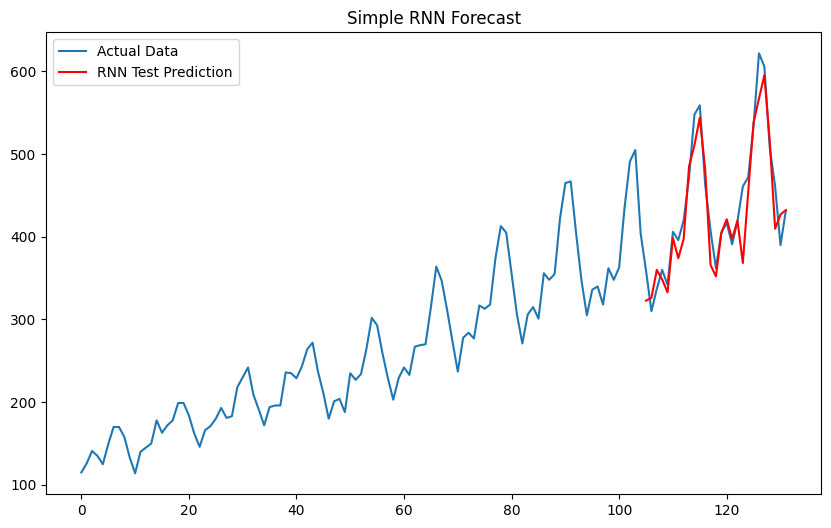

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
--- RNN LIVE DEMO (Sample 0) ---
Model Input (Past Data): [347 305 336 340 318 362 348 363 434 491 505 403]
Model Prediction: 323
Actual Value:     359
Difference:       36 passengers
Result: NEEDS IMPROVEMENT


In [20]:
class AirlineModel:
    def __init__(self,file_path,look_back=12,test_size = 0.3):
        self.file_path = file_path
        self.look_back = look_back
        self.scaler = MinMaxScaler(feature_range=(0,1))
        self.model = None

    def load_and_prepare(self):
        df = pd.read_csv(self.file_path,usecols=[1])
        data = df.values.astype('float32')

        scaled_data = self.scaler.fit_transform(data)

        X,y = [], []
        for i in range(len(scaled_data)-self.look_back):
            X.append(scaled_data[i:(i+self.look_back),0])
            y.append(scaled_data[i + self.look_back, 0])
        X, y = np.array(X), np.array(y)

        self.X = np.reshape(X, (X.shape[0], X.shape[1], 1))
        self.y = y

        train_size = int(len(self.X) * 0.8)
        self.X_train, self.X_test = self.X[:train_size], self.X[train_size:]
        self.y_train, self.y_test = self.y[:train_size], self.y[train_size:]

    def build_and_train(self, epochs=20):
        print("Building Simple RNN...")
        self.model = Sequential([
            # Using SimpleRNN instead of LSTM
            SimpleRNN(64, input_shape=(self.look_back, 1), activation='relu'),
            Dense(1)
        ])
        self.model.compile(optimizer='adam', loss='mean_squared_error')
        print("Training...")
        self.model.fit(self.X_train, self.y_train, epochs=epochs, batch_size=1, verbose=1)
    def evaluate(self):
        print("Predicting...")
        train_predict = self.model.predict(self.X_train)
        test_predict = self.model.predict(self.X_test)

        # Inverse transform to get actual passenger counts back
        train_predict = self.scaler.inverse_transform(train_predict)
        test_predict = self.scaler.inverse_transform(test_predict)

        # Plotting the results
        plt.figure(figsize=(10,6))
        plt.plot(self.scaler.inverse_transform(self.y.reshape(-1,1)), label="Actual Data")

        # Adjust plot for the 'look_back' offset
        test_plot = np.empty_like(self.y).reshape(-1,1)
        test_plot[:, :] = np.nan
        test_plot[len(train_predict):len(self.y), :] = test_predict

        plt.plot(test_plot, label="RNN Test Prediction", color='red')
        plt.title("Simple RNN Forecast")
        plt.legend()
        plt.show()


    def rnn_prediction_demo(self, sample_index=0): # Added self, removed other args
        # 1. Take a single sequence from your test set
        input_sequence = self.X_test[sample_index].reshape(1, self.X_test.shape[1], 1)

        # 2. Predict the next value
        scaled_prediction = self.model.predict(input_sequence)

        # 3. Inverse transform using self.scaler
        prediction = self.scaler.inverse_transform(scaled_prediction)[0][0]
        actual = self.scaler.inverse_transform(self.y_test[sample_index].reshape(-1, 1))[0][0]

        # 4. Print the result
        print(f"--- RNN LIVE DEMO (Sample {sample_index}) ---")
        print(f"Model Input (Past Data): {self.scaler.inverse_transform(self.X_test[sample_index]).flatten().astype(int)}")
        print(f"Model Prediction: {round(prediction)}")

        print(f"Actual Value:     {actual:.0f}")

        error = abs(prediction - actual)
        # This rounds the difference to 0 decimal places
        print(f"Difference:       {round(error)} passengers")


        if error < 15:
            print("Result: EXCELLENT")
        else:
            print("Result: NEEDS IMPROVEMENT")


# Execution
DATA_URL = 'airline-passengers.csv'
rnn_project = AirlineModel(DATA_URL)
rnn_project.load_and_prepare()
rnn_project.build_and_train(epochs=50)
rnn_project.evaluate()
rnn_project.rnn_prediction_demo()

